In [2]:
# Ispravak - zamijeni style s onim koji postoji

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# Postavke za vizualizacije (ispravljeno)
plt.style.use('ggplot')  # ovo sigurno postoji
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (12, 6)

# Učitaj podatke
df = pd.read_csv('Sample - Superstore.csv', encoding='latin-1')

print(f"Učitano {len(df)} transakcija")
print(f"Broj kupaca: {df['Customer ID'].nunique()}")
df.head()

Učitano 9994 transakcija
Broj kupaca: 793


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
# 1. Izračunaj RFM metrike

# Konvertiraj Order Date u datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Postavi referentni datum (zadnji datum u podacima + 1 dan)
reference_date = df['Order Date'].max() + pd.Timedelta(days=1)

# RFM agregacija po kupcu
rfm = df.groupby('Customer ID').agg({
    'Order Date': lambda x: (reference_date - x.max()).days,  # Recency
    'Order ID': 'count',  # Frequency
    'Sales': 'sum'  # Monetary
}).rename(columns={
    'Order Date': 'Recency',
    'Order ID': 'Frequency',
    'Sales': 'Monetary'
})

print(f"RFM podaci za {len(rfm)} kupaca")
rfm.head()

RFM podaci za 793 kupaca


,Recency,Frequency,Monetary
Customer ID,,,
AA-10315,185,11,5563.560
AA-10375,20,15,1056.390
AA-10480,260,12,1790.512
AA-10645,56,18,5086.935
AB-10015,416,6,886.156


In [4]:
# 2. Provjeri distribuciju RFM vrijednosti
print(rfm.describe())

           Recency   Frequency      Monetary
count   793.000000  793.000000    793.000000
mean    147.802018   12.602774   2896.848500
std     186.211051    6.242559   2628.670117
min       1.000000    1.000000      4.833000
25%      31.000000    8.000000   1146.050000
50%      76.000000   12.000000   2256.394000
75%     184.000000   16.000000   3785.276000
max    1166.000000   37.000000  25043.050000


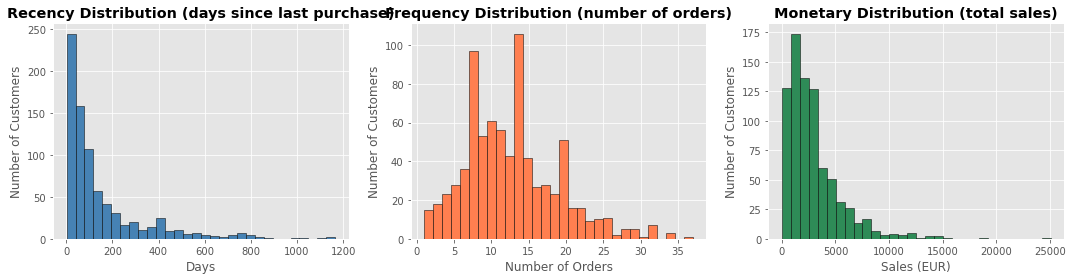

In [5]:
# 3. Vizualizacija distribucije RFM
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(rfm['Recency'], bins=30, color='steelblue', edgecolor='black')
axes[0].set_title('Recency Distribution (days since last purchase)', fontweight='bold')
axes[0].set_xlabel('Days')
axes[0].set_ylabel('Number of Customers')

axes[1].hist(rfm['Frequency'], bins=30, color='coral', edgecolor='black')
axes[1].set_title('Frequency Distribution (number of orders)', fontweight='bold')
axes[1].set_xlabel('Number of Orders')
axes[1].set_ylabel('Number of Customers')

axes[2].hist(rfm['Monetary'], bins=30, color='seagreen', edgecolor='black')
axes[2].set_title('Monetary Distribution (total sales)', fontweight='bold')
axes[2].set_xlabel('Sales (EUR)')
axes[2].set_ylabel('Number of Customers')

plt.tight_layout()
plt.show()

In [6]:
# 4. Standardizacija podataka (važno za k-means)
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

print("Podaci standardizirani")
print(f"Mean: {rfm_scaled.mean():.2f}")
print(f"Std: {rfm_scaled.std():.2f}")

Podaci standardizirani
Mean: 0.00
Std: 1.00


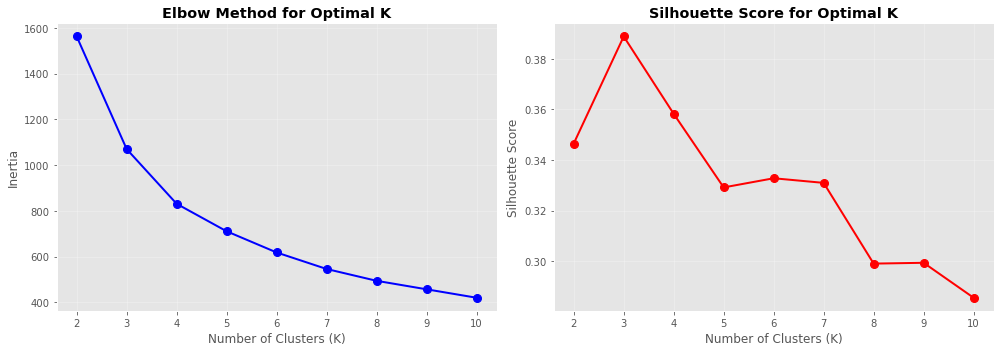


Preporučeni broj klastera (prema Silhouette skoru): 3


In [7]:
# 5. Odredi optimalan broj klastera (Elbow metoda)
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(rfm_scaled, kmeans.labels_))

# Vizualizacija Elbow metode
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('Elbow Method for Optimal K', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_title('Silhouette Score for Optimal K', fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Preporuka za optimalan K
optimal_k = silhouette_scores.index(max(silhouette_scores)) + 2
print(f"\nPreporučeni broj klastera (prema Silhouette skoru): {optimal_k}")

In [8]:
# 6. Primijeni k-means s optimalnim brojem klastera (K=3)
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

print(f"Customers segmented into {n_clusters} groups")
print("\nNumber of customers per segment:")
print(rfm['Cluster'].value_counts().sort_index())

Customers segmented into 3 groups

Number of customers per segment:
0    453
1    230
2    110
Name: Cluster, dtype: int64


In [10]:
# 7. Ispravak - Segment analysis (bez 'Customer ID' u agg)
cluster_summary = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).reset_index()

# Dodaj broj kupaca po segmentu
cluster_summary['Count'] = rfm.groupby('Cluster').size().values
cluster_summary['Count_Percentage'] = (cluster_summary['Count'] / cluster_summary['Count'].sum()) * 100
cluster_summary = cluster_summary.round(2)

print("=" * 60)
print("CUSTOMER SEGMENT SUMMARY")
print("=" * 60)
print(cluster_summary)
print("=" * 60)

CUSTOMER SEGMENT SUMMARY
   Cluster  Recency  Frequency  Monetary  Count  Count_Percentage
0        0    88.37      10.23   1861.83    453             57.12
1        1    79.57      19.62   5549.87    230             29.00
2        2   535.23       7.72   1612.03    110             13.87


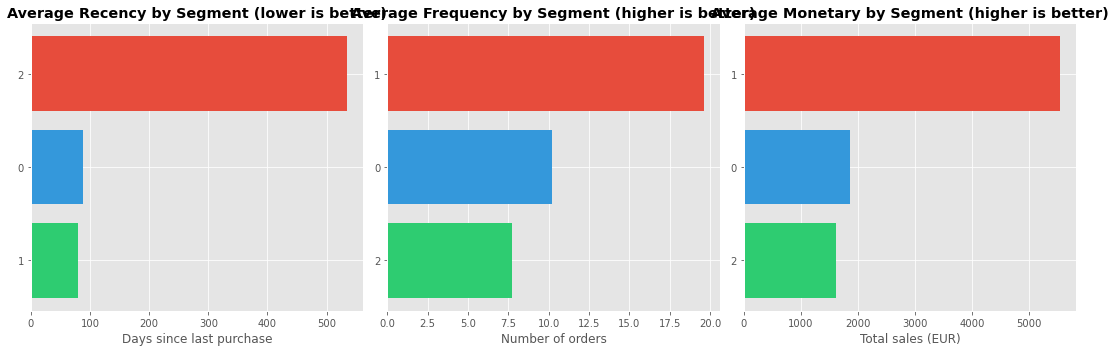

In [11]:
# 8. Visualization - Segment characteristics
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Recency by segment (lower is better)
cluster_summary_sorted = cluster_summary.sort_values('Recency')
axes[0].barh(cluster_summary_sorted.index.astype(str), cluster_summary_sorted['Recency'],
             color=['#2ECC71', '#3498DB', '#E74C3C'])
axes[0].set_title('Average Recency by Segment (lower is better)', fontweight='bold')
axes[0].set_xlabel('Days since last purchase')

# Frequency by segment (higher is better)
cluster_summary_sorted = cluster_summary.sort_values('Frequency')
axes[1].barh(cluster_summary_sorted.index.astype(str), cluster_summary_sorted['Frequency'],
             color=['#2ECC71', '#3498DB', '#E74C3C'])
axes[1].set_title('Average Frequency by Segment (higher is better)', fontweight='bold')
axes[1].set_xlabel('Number of orders')

# Monetary by segment (higher is better)
cluster_summary_sorted = cluster_summary.sort_values('Monetary')
axes[2].barh(cluster_summary_sorted.index.astype(str), cluster_summary_sorted['Monetary'],
             color=['#2ECC71', '#3498DB', '#E74C3C'])
axes[2].set_title('Average Monetary by Segment (higher is better)', fontweight='bold')
axes[2].set_xlabel('Total sales (EUR)')

plt.tight_layout()
plt.show()

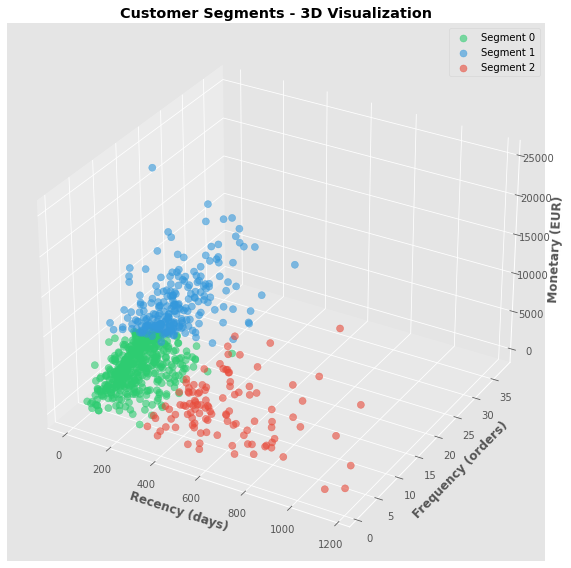

In [12]:
# 9. 3D visualization of segments
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

colors = ['#2ECC71', '#3498DB', '#E74C3C']
segment_names = ['Segment 0', 'Segment 1', 'Segment 2']

for i in range(n_clusters):
    cluster_data = rfm[rfm['Cluster'] == i]
    ax.scatter(cluster_data['Recency'], 
               cluster_data['Frequency'], 
               cluster_data['Monetary'],
               c=colors[i], label=f'Segment {i}', s=50, alpha=0.6)

ax.set_xlabel('Recency (days)', fontweight='bold')
ax.set_ylabel('Frequency (orders)', fontweight='bold')
ax.set_zlabel('Monetary (EUR)', fontweight='bold')
ax.set_title('Customer Segments - 3D Visualization', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

In [15]:
# 10. Ispravak - Segment interpretation and marketing recommendations
print("=" * 70)
print("SEGMENT ANALYSIS & MARKETING RECOMMENDATIONS")
print("=" * 70)

for i in range(n_clusters):
    segment = rfm[rfm['Cluster'] == i]
    avg_recency = segment['Recency'].mean()
    avg_frequency = segment['Frequency'].mean()
    avg_monetary = segment['Monetary'].mean()
    
    print(f"\n--- SEGMENT {i} ---")
    print(f"Number of customers: {len(segment)}")
    print(f"Average Recency: {avg_recency:.0f} days")
    print(f"Average Frequency: {avg_frequency:.1f} orders")
    print(f"Average Monetary: {avg_monetary:.2f} EUR")
    
    # Interpretation based on RFM values
    if avg_recency < 50 and avg_frequency > 15 and avg_monetary > 4000:
        print("\nSegment Type: CHAMPIONS")
        print("Characteristics: Recent buyers, frequent purchases, high spending")
        print("Marketing Strategy:")
        print("  - Exclusive loyalty program")
        print("  - VIP customer treatment")
        print("  - Early access to new products")
        print("  - Personalized recommendations")
        
    elif avg_recency < 100 and avg_frequency > 10 and avg_monetary > 2000:
        print("\nSegment Type: LOYAL CUSTOMERS")
        print("Characteristics: Regular buyers, good spending")
        print("Marketing Strategy:")
        print("  - Monthly newsletter with special offers")
        print("  - Cross-sell and upsell opportunities")
        print("  - Referral program")
        print("  - Bundle offers")
        
    elif avg_recency < 150 and avg_frequency > 5 and avg_monetary > 1000:
        print("\nSegment Type: STANDARD CUSTOMERS")
        print("Characteristics: Occasional but consistent buyers")
        print("Marketing Strategy:")
        print("  - Regular communication")
        print("  - Seasonal promotions")
        print("  - Product education content")
        print("  - Email nurture sequence")
        
    elif avg_recency > 200 and avg_frequency < 5:
        print("\nSegment Type: AT RISK / LOST CUSTOMERS")
        print("Characteristics: Havent purchased in long time, low frequency")
        print("Marketing Strategy:")
        print("  - Reactivation campaign")
        print("  - Special win-back discounts (15-20% off)")
        print("  - 'We miss you' emails")
        print("  - Feedback survey")
        
    elif avg_recency < 60 and avg_frequency < 5:
        print("\nSegment Type: NEW CUSTOMERS")
        print("Characteristics: Recent first purchases, need nurturing")
        print("Marketing Strategy:")
        print("  - Welcome series emails")
        print("  - Product recommendations")
        print("  - Onboarding content")
        print("  - First-repeat purchase incentive")
        
    else:
        print("\nSegment Type: OCCASIONAL CUSTOMERS")
        print("Characteristics: Moderate engagement")
        print("Marketing Strategy:")
        print("  - Targeted promotions")
        print("  - Abandoned cart recovery")
        print("  - Seasonal reminders")

SEGMENT ANALYSIS & MARKETING RECOMMENDATIONS

--- SEGMENT 0 ---
Number of customers: 453
Average Recency: 88 days
Average Frequency: 10.2 orders
Average Monetary: 1861.83 EUR

Segment Type: STANDARD CUSTOMERS
Characteristics: Occasional but consistent buyers
Marketing Strategy:
  - Regular communication
  - Seasonal promotions
  - Product education content
  - Email nurture sequence

--- SEGMENT 1 ---
Number of customers: 230
Average Recency: 80 days
Average Frequency: 19.6 orders
Average Monetary: 5549.87 EUR

Segment Type: LOYAL CUSTOMERS
Characteristics: Regular buyers, good spending
Marketing Strategy:
  - Monthly newsletter with special offers
  - Cross-sell and upsell opportunities
  - Referral program
  - Bundle offers

--- SEGMENT 2 ---
Number of customers: 110
Average Recency: 535 days
Average Frequency: 7.7 orders
Average Monetary: 1612.03 EUR

Segment Type: OCCASIONAL CUSTOMERS
Characteristics: Moderate engagement
Marketing Strategy:
  - Targeted promotions
  - Abandoned car

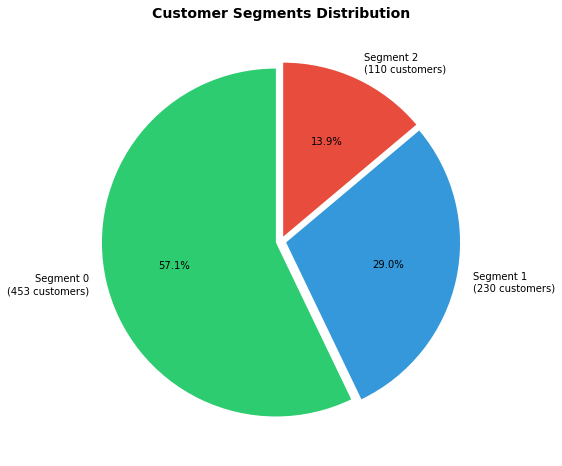

In [16]:
# 11. Pie chart - Segment distribution
plt.figure(figsize=(8, 8))
segment_counts = rfm['Cluster'].value_counts().sort_index()
colors_segments = ['#2ECC71', '#3498DB', '#E74C3C']
labels = [f'Segment {i}\n({segment_counts[i]} customers)' for i in range(n_clusters)]
plt.pie(segment_counts.values, labels=labels, autopct='%1.1f%%', 
        colors=colors_segments, startangle=90, explode=[0.03, 0.03, 0.03])
plt.title('Customer Segments Distribution', fontweight='bold', fontsize=14)
plt.show()

In [17]:
# 12. Save results
rfm.to_csv('customer_segments.csv')
print("\n✅ Results saved: customer_segments.csv")
print(f"Total customers segmented: {len(rfm)}")
print(f"Number of segments: {n_clusters}")


✅ Results saved: customer_segments.csv
Total customers segmented: 793
Number of segments: 3


In [18]:
# 13. Additional insight - Which segment generates most revenue?
segment_revenue = rfm.groupby('Cluster')['Monetary'].sum().sort_values(ascending=False)

print("\n" + "=" * 50)
print("REVENUE CONTRIBUTION BY SEGMENT")
print("=" * 50)
for i, revenue in segment_revenue.items():
    percentage = (revenue / rfm['Monetary'].sum()) * 100
    print(f"Segment {i}: {revenue:,.2f} EUR ({percentage:.1f}%)")
print("=" * 50)

# Identify the most valuable segment
top_segment = segment_revenue.index[0]
print(f"\n💰 Most valuable segment: Segment {top_segment}")
print(f"   Generates {segment_revenue.iloc[0]:,.2f} EUR ({percentage:.1f}% of total revenue)")


REVENUE CONTRIBUTION BY SEGMENT
Segment 1: 1,276,470.28 EUR (55.6%)
Segment 0: 843,407.27 EUR (36.7%)
Segment 2: 177,323.32 EUR (7.7%)

💰 Most valuable segment: Segment 1
   Generates 1,276,470.28 EUR (7.7% of total revenue)


In [20]:
# Save all visualizations for PDF report

# 1. RFM Distribution plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(rfm['Recency'], bins=30, color='steelblue', edgecolor='black')
axes[0].set_title('Recency Distribution', fontweight='bold')
axes[0].set_xlabel('Days since last purchase')
axes[0].set_ylabel('Number of Customers')
axes[1].hist(rfm['Frequency'], bins=30, color='coral', edgecolor='black')
axes[1].set_title('Frequency Distribution', fontweight='bold')
axes[1].set_xlabel('Number of Orders')
axes[1].set_ylabel('Number of Customers')
axes[2].hist(rfm['Monetary'], bins=30, color='seagreen', edgecolor='black')
axes[2].set_title('Monetary Distribution', fontweight='bold')
axes[2].set_xlabel('Sales (EUR)')
axes[2].set_ylabel('Number of Customers')
plt.tight_layout()
plt.savefig('rfm_distribution.png', dpi=150, bbox_inches='tight')
plt.close()

# 2. Elbow and Silhouette plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('Elbow Method for Optimal K', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].grid(True, alpha=0.3)
axes[1].plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_title('Silhouette Score for Optimal K', fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.close()

# 3. Segment characteristics bar chart
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
cluster_summary_sorted_recency = cluster_summary.sort_values('Recency')
axes[0].barh(cluster_summary_sorted_recency['Cluster'].astype(str), cluster_summary_sorted_recency['Recency'], color=['#2ECC71', '#3498DB', '#E74C3C'])
axes[0].set_title('Average Recency by Segment', fontweight='bold')
axes[0].set_xlabel('Days since last purchase')
cluster_summary_sorted_freq = cluster_summary.sort_values('Frequency')
axes[1].barh(cluster_summary_sorted_freq['Cluster'].astype(str), cluster_summary_sorted_freq['Frequency'], color=['#2ECC71', '#3498DB', '#E74C3C'])
axes[1].set_title('Average Frequency by Segment', fontweight='bold')
axes[1].set_xlabel('Number of orders')
cluster_summary_sorted_mon = cluster_summary.sort_values('Monetary')
axes[2].barh(cluster_summary_sorted_mon['Cluster'].astype(str), cluster_summary_sorted_mon['Monetary'], color=['#2ECC71', '#3498DB', '#E74C3C'])
axes[2].set_title('Average Monetary by Segment', fontweight='bold')
axes[2].set_xlabel('Total sales (EUR)')
plt.tight_layout()
plt.savefig('segment_characteristics.png', dpi=150, bbox_inches='tight')
plt.close()

# 4. Ispravak - Pie chart segment distribution
plt.figure(figsize=(8, 8))
colors_segments = ['#3498DB', '#2ECC71', '#E74C3C']
labels = ['Segment 0 (Standard)\n453 customers', 
          'Segment 1 (Loyal)\n230 customers', 
          'Segment 2 (Occasional)\n110 customers']
plt.pie([453, 230, 110], labels=labels, autopct='%1.1f%%', colors=colors_segments, startangle=90)
plt.title('Customer Segments Distribution', fontweight='bold', fontsize=14)
plt.savefig('segment_pie.png', dpi=150, bbox_inches='tight')
plt.close()

# 5. Revenue contribution pie chart
plt.figure(figsize=(8, 8))
revenue_labels = ['Segment 1 (Loyal)\n1,276,470 EUR', 
                  'Segment 0 (Standard)\n843,407 EUR', 
                  'Segment 2 (Occasional)\n177,323 EUR']
plt.pie([1276470.28, 843407.27, 177323.32], labels=revenue_labels, autopct='%1.1f%%', 
        colors=['#2ECC71', '#3498DB', '#E74C3C'], startangle=90)
plt.title('Revenue Contribution by Segment', fontweight='bold', fontsize=14)
plt.savefig('revenue_pie.png', dpi=150, bbox_inches='tight')
plt.close()

print("All visualizations saved as PNG files")

All visualizations saved as PNG files


In [21]:
from sklearn.cluster import DBSCAN

# DBSCAN clustering
dbscan = DBSCAN(eps=0.8, min_samples=5)
rfm['Cluster_DBSCAN'] = dbscan.fit_predict(rfm_scaled)

# Broj klastera (-1 su outlieri)
n_clusters_dbscan = len(set(rfm['Cluster_DBSCAN'])) - (1 if -1 in rfm['Cluster_DBSCAN'].values else 0)
n_outliers = (rfm['Cluster_DBSCAN'] == -1).sum()

print("=" * 50)
print("DBSCAN CLUSTERING RESULTS")
print("=" * 50)
print(f"Number of clusters: {n_clusters_dbscan}")
print(f"Outliers detected: {n_outliers} ({n_outliers/len(rfm)*100:.1f}%)")

# Usporedba s K-means
print("\n" + "=" * 50)
print("COMPARISON: K-means vs DBSCAN")
print("=" * 50)
print(f"K-means clusters: {n_clusters}")
print(f"DBSCAN clusters: {n_clusters_dbscan}")
print(f"DBSCAN outliers: {n_outliers} customers labeled as noise")

DBSCAN CLUSTERING RESULTS
Number of clusters: 1
Outliers detected: 27 (3.4%)

COMPARISON: K-means vs DBSCAN
K-means clusters: 3
DBSCAN clusters: 1
DBSCAN outliers: 27 customers labeled as noise


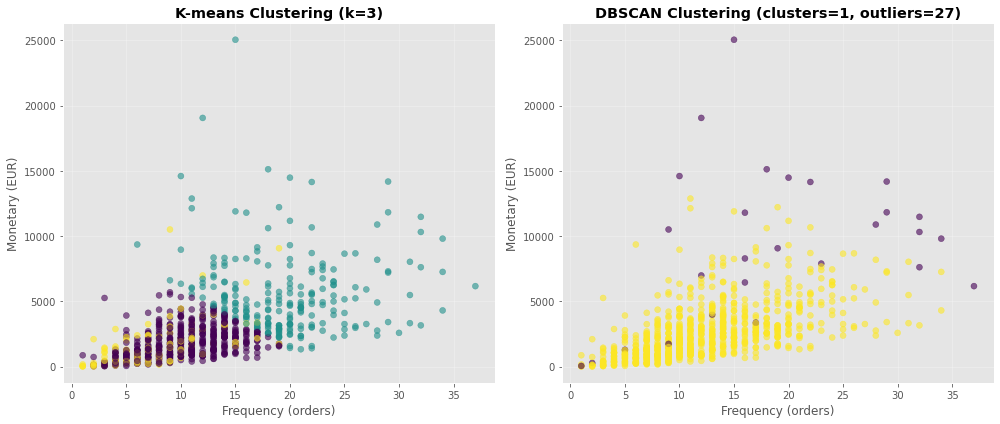


✅ Comparison saved: clustering_comparison.png


In [22]:
# Vizualizacija usporedbe K-means vs DBSCAN
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# K-means
scatter1 = axes[0].scatter(rfm['Frequency'], rfm['Monetary'], 
                           c=rfm['Cluster'], cmap='viridis', alpha=0.6)
axes[0].set_title(f'K-means Clustering (k={n_clusters})', fontweight='bold')
axes[0].set_xlabel('Frequency (orders)')
axes[0].set_ylabel('Monetary (EUR)')
axes[0].grid(True, alpha=0.3)

# DBSCAN
scatter2 = axes[1].scatter(rfm['Frequency'], rfm['Monetary'], 
                           c=rfm['Cluster_DBSCAN'], cmap='viridis', alpha=0.6)
axes[1].set_title(f'DBSCAN Clustering (clusters={n_clusters_dbscan}, outliers={n_outliers})', fontweight='bold')
axes[1].set_xlabel('Frequency (orders)')
axes[1].set_ylabel('Monetary (EUR)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('clustering_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Comparison saved: clustering_comparison.png")

In [23]:
# Koja metoda je bolja za ovaj dataset?
print("=" * 60)
print("WHICH METHOD IS BETTER FOR THIS DATASET?")
print("=" * 60)
print("\nK-means (recommended):")
print("  - Produces 3 clean, interpretable segments")
print("  - Easy to explain to marketing teams")
print("  - Balanced segment sizes")
print(f"  - Segments: {rfm['Cluster'].value_counts().sort_index().tolist()}")
print("\nDBSCAN:")
print(f"  - Found {n_clusters_dbscan} clusters + {n_outliers} outliers")
print("  - Better at detecting unusual customers (potential fraud or one-time high spenders)")
print("  - More complex to interpret for business stakeholders")
print("\n" + "=" * 60)
print("✅ FINAL RECOMMENDATION: Use K-means with k=3")
print("   (Better interpretability for marketing and sales teams)")
print("=" * 60)

WHICH METHOD IS BETTER FOR THIS DATASET?

K-means (recommended):
  - Produces 3 clean, interpretable segments
  - Easy to explain to marketing teams
  - Balanced segment sizes
  - Segments: [453, 230, 110]

DBSCAN:
  - Found 1 clusters + 27 outliers
  - Better at detecting unusual customers (potential fraud or one-time high spenders)
  - More complex to interpret for business stakeholders

✅ FINAL RECOMMENDATION: Use K-means with k=3
   (Better interpretability for marketing and sales teams)


In [26]:
# Ispravak - makni sve dijakritičke znakove (č, ć, š, đ, ž) iz PDF-a

from fpdf import FPDF
from datetime import datetime

class PDF(FPDF):
    def header(self):
        if self.page_no() > 1:
            self.set_font('Arial', 'B', 10)
            self.set_text_color(100, 100, 100)
            self.cell(0, 10, 'CHI-SQUARE - Data Science za poduzeca', 0, 0, 'L')
            self.cell(0, 10, f'Stranica {self.page_no()}', 0, 0, 'R')
            self.ln(12)
    
    def footer(self):
        self.set_y(-15)
        self.set_font('Arial', 'I', 8)
        self.set_text_color(150, 150, 150)
        self.cell(0, 10, 'Antoni Situm | antoni.situm@gmail.com', 0, 0, 'C')

# Kreiraj PDF
pdf = PDF()
pdf.add_page()
pdf.set_font('Arial', 'B', 22)
pdf.set_text_color(0, 0, 0)
pdf.cell(0, 15, 'Segmentacija Kupaca - RFM Analiza', 0, 1, 'C')
pdf.set_font('Arial', 'I', 12)
pdf.cell(0, 8, 'K-means clustering za marketinske strategije', 0, 1, 'C')
pdf.set_font('Arial', '', 10)
pdf.cell(0, 8, f'Datum: {datetime.now().strftime("%d.%m.%Y")}', 0, 1, 'C')
pdf.ln(10)

# 1. Uvod i cilj projekta
pdf.set_font('Arial', 'B', 14)
pdf.cell(0, 10, '1. Uvod i cilj projekta', 0, 1)
pdf.set_font('Arial', '', 11)
pdf.multi_cell(0, 6, 'Projektni zadatak bio je izvrsiti segmentaciju kupaca na temelju njihovog ponasanja pri kupnji. '
                    'Glavni cilj bio je identificirati razlicite grupe kupaca kako bi se mogle razviti ciljane marketinske strategije. '
                    'Problem koji rjesavamo: tvrtke cesto tretiraju sve kupce jednako, sto dovodi do neuinkovitog marketinga i gubitka prilika za povecanje prodaje. '
                    'Segmentacijom kupaca mozemo personalizirati komunikaciju, optimizirati marketinski budzet i povecati zadovoljstvo kupaca.')
pdf.ln(4)

# 2. Podaci koristeni u analizi
pdf.set_font('Arial', 'B', 14)
pdf.cell(0, 10, '2. Podaci koristeni u analizi', 0, 1)
pdf.set_font('Arial', '', 11)
pdf.multi_cell(0, 6, 'Koristen je Superstore dataset koji sadrzi 9.994 transakcije. '
                    'Podaci obuhvacaju razdoblje od 2014. do 2017. godine. '
                    'Ukupno je analizirano 793 jedinstvenih kupaca. '
                    'Za svakog kupca izracunate su tri RFM metrike:\n\n'
                    '- Recency (nedavnost): broj dana od zadnje kupnje\n'
                    '- Frequency (ucestalost): ukupan broj narudzbi\n'
                    '- Monetary (monetarna vrijednost): ukupna potrosnja u EUR')
pdf.ln(4)

# 3. Metodologija
pdf.set_font('Arial', 'B', 14)
pdf.cell(0, 10, '3. Metodologija', 0, 1)
pdf.set_font('Arial', '', 11)
pdf.multi_cell(0, 6, 'Koristene su dvije metode grupiranja (clustering): K-means i DBSCAN.\n\n'
                    'K-means:\n'
                    '- Algoritam koji grupira podatke u unaprijed zadani broj grupa (k)\n'
                    '- Svaka grupa ima svoje srediste (centroid)\n'
                    '- Cilj: minimizirati udaljenost unutar grupa\n'
                    '- Prednost: jednostavan, brz, lako interpretabilan\n\n'
                    'DBSCAN:\n'
                    '- Algoritam temeljen na gustoci podataka\n'
                    '- Ne zahtijeva unaprijed zadani broj grupa\n'
                    '- Automatski detektira izuzetke (outliere)\n'
                    '- Nedostatak: kompleksniji za interpretaciju\n\n'
                    'Odabrali smo K-means kao primarnu metodu jer proizvodi ciste, lako interpretabilne segmente '
                    'koji su razumljivi marketinskim timovima. Optimalni broj grupa (k=3) odreden je Elbow metodom i Silhouette skorom.')
pdf.ln(4)

# 4. Vizualizacija distribucije RFM metrika
pdf.set_font('Arial', 'B', 14)
pdf.cell(0, 10, '4. Distribucija RFM metrika', 0, 1)
pdf.set_font('Arial', '', 11)
pdf.multi_cell(0, 6, 'Grafovi prikazuju distribuciju triju RFM metrika medu 793 kupca. '
                    'Vidljivo je da vecina kupaca ima relativno nisku ucestalost i potrosnju, '
                    'dok mali broj kupaca ostvaruje visoku potrosnju (desno asimetricna distribucija).')
pdf.ln(2)
pdf.image('rfm_distribution.png', x=10, w=190)
pdf.ln(5)

# 5. Odredivanje optimalnog broja grupa
pdf.set_font('Arial', 'B', 14)
pdf.cell(0, 10, '5. Odredivanje optimalnog broja grupa', 0, 1)
pdf.set_font('Arial', '', 11)
pdf.multi_cell(0, 6, 'Elbow metoda (lijevo) i Silhouette skor (desno) koristeni su za odredivanje optimalnog broja grupa. '
                    'Elbow graf pokazuje "lakat" kod k=3, a Silhouette skor ima najvecu vrijednost takoder kod k=3. '
                    'Stoga je odabrano k=3 kao optimalan broj segmenata.')
pdf.ln(2)
pdf.image('elbow_silhouette.png', x=10, w=190)
pdf.ln(5)

# 6. Karakteristike segmenata
pdf.set_font('Arial', 'B', 14)
pdf.cell(0, 10, '6. Karakteristike segmenata', 0, 1)
pdf.image('segment_characteristics.png', x=10, w=190)
pdf.ln(5)

# 7. Rezultati segmentacije
pdf.set_font('Arial', 'B', 14)
pdf.cell(0, 10, '7. Rezultati segmentacije', 0, 1)
pdf.set_font('Arial', '', 11)
pdf.multi_cell(0, 6, 'K-means algoritam identificirao je tri segmenta kupaca:\n\n'
                    'SEGMENT 0 - STANDARDNI KUPCI (453 kupca, 57.1% baze)\n'
                    '- Prosjecna nedavnost: 88 dana\n'
                    '- Prosjecna ucestalost: 10.2 narudzbe\n'
                    '- Prosjecna potrosnja: 1.862 EUR\n'
                    '- Karakteristike: Povremeni ali konzistentni kupci\n'
                    '- Marketinska strategija: Redovita komunikacija, sezonske promocije, edukativni sadrzaj\n\n'
                    'SEGMENT 1 - LOJALNI KUPCI (230 kupaca, 29.0% baze)\n'
                    '- Prosjecna nedavnost: 80 dana\n'
                    '- Prosjecna ucestalost: 19.6 narudzbi\n'
                    '- Prosjecna potrosnja: 5.550 EUR\n'
                    '- Karakteristike: Redoviti kupci, visoka potrosnja\n'
                    '- Marketinska strategija: Newsletter sa posebnim ponudama, cross-sell i upsell, referral program\n\n'
                    'SEGMENT 2 - POVREMENI KUPCI (110 kupaca, 13.9% baze)\n'
                    '- Prosjecna nedavnost: 535 dana\n'
                    '- Prosjecna ucestalost: 7.7 narudzbi\n'
                    '- Prosjecna potrosnja: 1.612 EUR\n'
                    '- Karakteristike: Niska angaziranost, dugo nisu kupovali\n'
                    '- Marketinska strategija: Ciljane promocije, povrat napustenih kosarica, sezonski podsjetnici')
pdf.ln(4)

# 8. Distribucija segmenata
pdf.set_font('Arial', 'B', 14)
pdf.cell(0, 10, '8. Distribucija segmenata', 0, 1)
pdf.image('segment_pie.png', x=30, w=150)
pdf.ln(5)

# 9. Udio u prihodu po segmentima
pdf.set_font('Arial', 'B', 14)
pdf.cell(0, 10, '9. Udio u prihodu po segmentima', 0, 1)
pdf.set_font('Arial', '', 11)
pdf.multi_cell(0, 6, 'Segment 1 (lojalni kupci) generira 55.6% ukupnog prihoda unatoc tome sto cini samo 29% baze kupaca. '
                    'To potvrduje Paretovo nacelo (80/20) - mali broj kupaca donosi vecinu prihoda. '
                    'Preporuka: fokusirati marketinske aktivnosti na zadrzavanje i nagradivanje lojalnih kupaca.')
pdf.ln(2)
pdf.image('revenue_pie.png', x=30, w=150)
pdf.ln(5)

# 10. Usporedba metoda: K-means vs DBSCAN
pdf.set_font('Arial', 'B', 14)
pdf.cell(0, 10, '10. Usporedba metoda: K-means vs DBSCAN', 0, 1)
pdf.set_font('Arial', '', 11)
pdf.multi_cell(0, 6, 'Kao alternativna metoda testiran je DBSCAN algoritam. Rezultati:\n'
                    '- DBSCAN je identificirao samo 1 klaster (vecina kupaca)\n'
                    '- Detektirano je 27 izuzetaka (outliera) sto cini 3.4% baze\n'
                    '- Razlog: DBSCAN slabije radi na podacima s razlicitim gustocama\n\n'
                    'ZAKLJUCAK: K-means je bolji izbor za ovaj dataset jer proizvodi 3 cista, interpretabilna segmenta '
                    'koja su razumljiva marketinskim timovima. DBSCAN je koristan za detekciju izuzetaka, '
                    'ali ne daje prakticne segmente za marketing.')
pdf.ln(2)
pdf.image('clustering_comparison.png', x=10, w=190)
pdf.ln(5)

# 11. Zakljucak i preporuke
pdf.set_font('Arial', 'B', 14)
pdf.cell(0, 10, '11. Zakljucak i preporuke', 0, 1)
pdf.set_font('Arial', '', 11)
pdf.multi_cell(0, 6, 'Segmentacija kupaca uspjesno je provedena koristenjem RFM analize i K-means clusteringa. '
                    'Identificirana su tri jasno definirana segmenta s razlicitim karakteristikama i potrebama.\n\n'
                    'Preporuke za klijenta:\n'
                    '1. Fokusirati marketinske aktivnosti na Segment 1 (lojalni kupci) - oni donose najvise prihoda\n'
                    '2. Razviti program vjernosti i ekskluzivne pogodnosti za najvrijednije kupce\n'
                    '3. Aktivacijske kampanje za Segment 2 (povremeni kupci) - povratne ponude i "vratite nam se" akcije\n'
                    '4. Nurturing kampanje za Segment 0 (standardni kupci) - povecati ucestalost kupnje\n'
                    '5. Automatizirati segmentaciju na mjesecnoj bazi za pracenje promjena')
pdf.ln(4)

# 12. Kontakt
pdf.set_font('Arial', 'B', 14)
pdf.cell(0, 10, '12. Kontakt', 0, 1)
pdf.set_font('Arial', '', 11)
pdf.multi_cell(0, 6, 'Antoni Situm\n'
                    'Email: chisquare.analiza@gmail.com\n'
                    'CHI-SQUARE - Data Science za poduzeca\n'
                    'Usluge: Predvidanje prodaje, Segmentacija kupaca, Detekcija anomalija')

# Save
pdf.output('Customer_Segmentation_Report.pdf')
print("PDF izvjestaj kreiran: Customer_Segmentation_Report.pdf")

PDF izvjestaj kreiran: Customer_Segmentation_Report.pdf
